## WW5 – Operational Robustness on high-frequency WWTP data (N2O): averaged operational curves

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [ ]:
# --- Upload file in Colab ---
from google.colab import files

uploaded = files.upload()
# Expecting: aved_raw.csv

In [ ]:
# --- Efficient CSV reading ---
CSV_PATH = "aved_raw.csv"

# 1) Read only the header to decide which columns to load
cols = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()

# 2) Keep time + selected signals (edit patterns if needed)
# We will focus on N2O + a small set of process signals.
keep_patterns = [
    "time",
    "N2O value", "N2O quality",
    "NH4 value", "NH4 quality",
    "NO3 value", "NO3 quality",
    "O2 value", "O2 quality",
    "Q.AIRFLOW value", "Q.AIRFLOW quality",
    "O2.SETPOINT value", "O2.SETPOINT quality",
    "PHASECODE.SETPOINT value", "PHASECODE.SETPOINT quality",
]

def should_keep(c):
    return any(p in c for p in keep_patterns)

usecols = [c for c in cols if should_keep(c)]

print("Columns loaded:", len(usecols))
usecols[:20]

Columns loaded: 23


['time',
 'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value',
 'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality',
 'BIOLOGY.LINE 3 TANK 1.N2O value',
 'BIOLOGY.LINE 3 TANK 1.N2O quality',
 'BIOLOGY.LINE 3 TANK 1.NH4 value',
 'BIOLOGY.LINE 3 TANK 1.NH4 quality',
 'BIOLOGY.LINE 3 TANK 1.NO3 value',
 'BIOLOGY.LINE 3 TANK 1.NO3 quality',
 'BIOLOGY.LINE 3 TANK 1.O2 value',
 'BIOLOGY.LINE 3 TANK 1.O2 quality',
 'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value',
 'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality',
 'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value',
 'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality',
 'BIOLOGY.LINE 3 TANK 2.O2 value',
 'BIOLOGY.LINE 3 TANK 2.O2 quality',
 'BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value',
 'BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality',
 'BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value']

In [ ]:
# --- Load selected columns ---
df = pd.read_csv(
    CSV_PATH,
    usecols=usecols,
    low_memory=False
)

# Parse time (timezone-aware strings)
df["time"] = pd.to_datetime(df["time"], utc=True)  # normalize to UTC for safety
df = df.sort_values("time").reset_index(drop=True)

df.head()

,time,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,BIOLOGY.LINE 3 TANK 1.O2 value,...,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 2.O2 value,BIOLOGY.LINE 3 TANK 2.O2 quality,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality,BIOLOGY.LINE 3.PHASECODE.SETPOINT value,BIOLOGY.LINE 3.PHASECODE.SETPOINT quality
0,2022-06-11 22:01:00+00:00,26829.375000,1.0,0.700231,0.0,1.66608,0.0,0.074907,0.0,0.058955,...,NaN,NaN,1.384549,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.507085,0.0,NaN,NaN,1222.0,0.0
2,2022-06-11 22:03:00+00:00,29626.341797,1.0,0.697917,0.0,1.52727,0.0,0.074907,0.0,0.079933,...,NaN,NaN,1.673177,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.432644,0.0,NaN,NaN,1222.0,0.0
4,2022-06-11 22:05:00+00:00,28605.208984,1.0,0.656829,0.0,1.43633,0.0,0.056901,0.0,0.330223,...,NaN,NaN,2.121311,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# --- Apply quality masks (optional but recommended) ---
value_cols = [c for c in df.columns if c.endswith(" value")]
quality_cols = [c for c in df.columns if c.endswith(" quality")]

# Map value col -> matching quality col (same prefix)
pairs = []
for v in value_cols:
    q = v.replace(" value", " quality")
    if q in df.columns:
        pairs.append((v, q))

print("Value/quality pairs:", len(pairs))

for v, q in pairs:
    # Keep values only when quality==0
    df.loc[df[q].notna() & (df[q] != 0), v] = np.nan

df[value_cols].isna().mean().sort_values(ascending=False).head(10)

Value/quality pairs: 11


,0
BIOLOGY.LINE 3 TANK 1.O2 value,0.497270
BIOLOGY.LINE 3 TANK 2.O2 value,0.475801
BIOLOGY.LINE 3 TANK 1.N2O value,0.468142
BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,0.457616
BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,0.457615
BIOLOGY.LINE 3 TANK 1.NH4 value,0.448890
BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,0.443614
BIOLOGY.LINE 3 TANK 1.NO3 value,0.425998
BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value,0.367109
BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,0.367109


In [ ]:
# --- Identify candidate N2O columns ---
n2o_cols = [c for c in df.columns if ("N2O value" in c)]
n2o_cols

['BIOLOGY.LINE 3 TANK 1.N2O value']

In [ ]:
# --- Choose target N2O signal ---
TARGET_N2O = "BIOLOGY.LINE 3 TANK 1.N2O value"  # change if needed
assert TARGET_N2O in df.columns, "TARGET_N2O not found. Pick one from n2o_cols above."

df[[ "time", TARGET_N2O ]].dropna().head()

,time,BIOLOGY.LINE 3 TANK 1.N2O value
0,2022-06-11 22:01:00+00:00,0.700231
2,2022-06-11 22:03:00+00:00,0.697917
4,2022-06-11 22:05:00+00:00,0.656829
6,2022-06-11 22:07:00+00:00,0.593171
8,2022-06-11 22:09:00+00:00,0.584491


In [ ]:
# --- Daily aggregation ---
df = df.set_index("time")

# Keep only value columns
X_raw = df[value_cols].copy()

# Daily aggregates (you can add more if you want)
daily_mean = X_raw.resample("1D").mean()
daily_std  = X_raw.resample("1D").std()
daily_min  = X_raw.resample("1D").min()
daily_max  = X_raw.resample("1D").max()

# Build feature table
F_daily = pd.concat(
    [daily_mean.add_suffix("_mean"),
     daily_std.add_suffix("_std"),
     daily_min.add_suffix("_min"),
     daily_max.add_suffix("_max")],
    axis=1
)

# Target series for event definition (daily max N2O)
n2o_daily_max = daily_max[TARGET_N2O].rename("N2O_max")

print("Daily samples:", F_daily.shape[0])
F_daily.head()

Daily samples: 732


,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value_mean,BIOLOGY.LINE 3 TANK 1.N2O value_mean,BIOLOGY.LINE 3 TANK 1.NH4 value_mean,BIOLOGY.LINE 3 TANK 1.NO3 value_mean,BIOLOGY.LINE 3 TANK 1.O2 value_mean,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value_mean,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value_mean,BIOLOGY.LINE 3 TANK 2.O2 value_mean,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value_mean,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value_mean,...,BIOLOGY.LINE 3 TANK 1.N2O value_max,BIOLOGY.LINE 3 TANK 1.NH4 value_max,BIOLOGY.LINE 3 TANK 1.NO3 value_max,BIOLOGY.LINE 3 TANK 1.O2 value_max,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value_max,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value_max,BIOLOGY.LINE 3 TANK 2.O2 value_max,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value_max,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value_max,BIOLOGY.LINE 3.PHASECODE.SETPOINT value_max
time,,,,,,,,,,,,,,,,,,,,,
2022-06-11 00:00:00+00:00,6908.148730,0.519049,1.671393,0.486282,0.496238,0.914226,NaN,0.681273,1.084295,NaN,...,0.723380,2.48621,1.445267,1.880425,1.375895,NaN,2.483362,2.0,NaN,2221.0
2022-06-12 00:00:00+00:00,7220.043280,0.530725,3.086742,1.358376,0.693303,1.226373,NaN,0.809456,1.137624,NaN,...,2.069444,11.43040,6.254797,3.246889,2.000000,NaN,3.689598,2.0,NaN,2222.0
2022-06-13 00:00:00+00:00,7212.932286,0.474389,2.136698,1.638075,0.562111,0.961407,NaN,0.844980,1.163772,NaN,...,2.069444,4.69316,11.150229,2.575232,1.834083,NaN,4.256366,2.0,NaN,2222.0
2022-06-14 00:00:00+00:00,8223.480177,0.184722,2.211468,2.016830,0.631319,1.013284,NaN,0.910028,1.232424,NaN,...,0.795718,5.34285,4.943898,3.232422,1.992570,NaN,3.634259,2.0,NaN,2222.0
2022-06-15 00:00:00+00:00,5830.454848,0.206727,2.747688,2.233155,0.650116,1.173382,NaN,0.932721,1.277907,NaN,...,0.781829,5.95214,5.058222,3.016131,2.000000,NaN,3.654514,2.0,NaN,2222.0


In [ ]:
# --- Chronological split (60/20/20) ---
N = len(F_daily)
i_train = int(0.60 * N)
i_val   = int(0.80 * N)

F_train = F_daily.iloc[:i_train].copy()
F_val   = F_daily.iloc[i_train:i_val].copy()
F_test  = F_daily.iloc[i_val:].copy()

n2o_train = n2o_daily_max.iloc[:i_train]
n2o_val   = n2o_daily_max.iloc[i_train:i_val]
n2o_test  = n2o_daily_max.iloc[i_val:]

(F_train.shape, F_val.shape, F_test.shape)

((439, 44), (146, 44), (147, 44))

In [ ]:
# --- Impute using train statistics, then standardize ---
mu = F_train.mean()
sd = F_train.std().replace(0, 1.0)

def transform(F):
    F2 = F.copy()
    F2 = F2.fillna(mu)
    F2 = (F2 - mu) / sd
    return F2

F_train_z = transform(F_train)
F_val_z   = transform(F_val)
F_test_z  = transform(F_test)

In [ ]:
# --- Define events by N2O peak severity (percentile on TRAIN) ---
PERCENTILE = 95  # try 95 or 97, later we can do a sensitivity sweep

thr = np.nanpercentile(n2o_train.values, PERCENTILE)
event_days = (n2o_daily_max >= thr)

print("Threshold:", thr)
print("Total event days:", int(event_days.sum()))
event_days.value_counts()

Threshold: 1.6592881739139553
Total event days: 21


,count
N2O_max,
False,711
True,21


In [ ]:
# --- Horizon labels ---
def make_horizon_labels(event_bool, H=3):
    # event_bool: pd.Series indexed by day
    e = event_bool.astype(int).values
    y = np.zeros_like(e)
    for i in range(len(e)):
        j1 = i + 1
        j2 = min(i + H, len(e)-1)
        if j1 <= j2 and e[j1:j2+1].sum() > 0:
            y[i] = 1
    return pd.Series(y, index=event_bool.index, name=f"y_H{H}")

H = 3
y = make_horizon_labels(event_days, H=H)

y.value_counts()

,count
y_H3,
0,682
1,50


In [ ]:
# --- Rolling-origin splits on daily data ---
def make_rolling_splits(n_days, train_frac=0.60, val_frac=0.20, n_splits=4):
    # returns list of (train_end, val_end, test_end) indices in [0..n_days)
    train_len = int(train_frac * n_days)
    val_len   = int(val_frac * n_days)
    test_len  = n_days - train_len - val_len
    step = max(1, test_len // n_splits)

    splits = []
    for s in range(n_splits):
        train_end = train_len + s * step
        val_end   = min(train_end + val_len, n_days - test_len)
        test_end  = min(val_end + test_len, n_days)
        if test_end <= val_end or val_end <= train_end:
            continue
        splits.append((train_end, val_end, test_end))
    return splits

splits = make_rolling_splits(len(F_daily), n_splits=4)
splits

[(439, 585, 732), (475, 585, 732), (511, 585, 732), (547, 585, 732)]

In [ ]:
# --- Event-based evaluation helpers ---
def false_alarms_per_30d(alert_bool):
    # alert_bool: pd.Series bool indexed by day
    days = len(alert_bool)
    if days == 0:
        return 0.0
    fa = int(alert_bool.sum())
    return fa * (30.0 / days)

def event_hit_rate(event_days_bool, alert_bool):
    # hit if any alert on an event day (simple, conservative)
    # Alternative: hit if alert occurs within pre-event window; but we already encode horizon in y.
    events = event_days_bool.astype(bool)
    n_events = int(events.sum())
    if n_events == 0:
        return np.nan
    hits = int((events & alert_bool).sum())
    return hits / n_events

def operational_curve(scores, event_days_bool, grid_fa=np.linspace(0, 25, 51)):
    """
    Build hit-rate vs FA/30d by sweeping thresholds, then interpolate on a FA grid.
    scores: pd.Series float
    """
    # candidate thresholds from score quantiles
    qs = np.linspace(0.0, 1.0, 200)
    ths = np.quantile(scores.dropna().values, qs)

    points = []
    for th in ths:
        alert = (scores >= th)
        fa30 = false_alarms_per_30d(alert)
        hr = event_hit_rate(event_days_bool, alert)
        points.append((fa30, hr))

    # sort by FA
    pts = pd.DataFrame(points, columns=["fa30", "hit_rate"]).sort_values("fa30")
    # remove duplicates for interpolation stability
    pts = pts.groupby("fa30", as_index=False)["hit_rate"].mean()

    # interpolate hit-rate over grid
    fa_vals = pts["fa30"].values
    hr_vals = pts["hit_rate"].values
    hr_interp = np.interp(grid_fa, fa_vals, hr_vals, left=hr_vals[0], right=hr_vals[-1])

    return grid_fa, hr_interp, pts

In [ ]:
# --- Train logistic regression and compute operational curves per split ---
def fit_lr_and_score(Fz, y_bin, train_idx, val_idx, test_idx):
    X_tr, y_tr = Fz.iloc[:train_idx], y_bin.iloc[:train_idx]
    X_va, y_va = Fz.iloc[train_idx:val_idx], y_bin.iloc[train_idx:val_idx]
    X_te, y_te = Fz.iloc[val_idx:test_idx], y_bin.iloc[val_idx:test_idx]

    # Class-balanced LR
    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    )
    clf.fit(X_tr, y_tr)

    s_va = pd.Series(clf.predict_proba(X_va)[:, 1], index=X_va.index)
    s_te = pd.Series(clf.predict_proba(X_te)[:, 1], index=X_te.index)

    return s_va, s_te, y_va, y_te

grid_fa = np.linspace(0, 25, 51)
curves = []

for (train_end, val_end, test_end) in splits:
    # Fit and score on the full standardized daily table (already no leakage by construction)
    s_val, s_test, y_val, y_test = fit_lr_and_score(
        pd.concat([F_train_z, F_val_z, F_test_z], axis=0),
        y,
        train_end, val_end, test_end
    )

    # Event days in TEST (event definition is global from threshold; OK for evaluation)
    ev_test = event_days.iloc[val_end:test_end]

    fa_grid, hr_grid, pts = operational_curve(s_test, ev_test, grid_fa=grid_fa)
    curves.append(hr_grid)

len(curves), [c.shape for c in curves][:2]

(4, [(51,), (51,)])

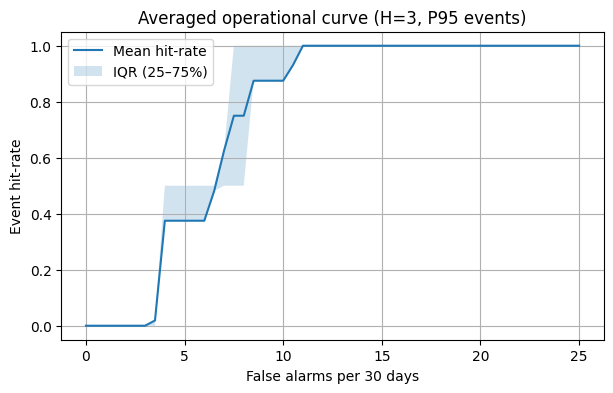

In [ ]:
# --- Average curves across splits ---
C = np.vstack(curves)  # [n_splits, len(grid)]
hr_mean = np.nanmean(C, axis=0)
hr_p25  = np.nanpercentile(C, 25, axis=0)
hr_p75  = np.nanpercentile(C, 75, axis=0)

# Plot
plt.figure(figsize=(7,4))
plt.plot(grid_fa, hr_mean, label="Mean hit-rate")
plt.fill_between(grid_fa, hr_p25, hr_p75, alpha=0.2, label="IQR (25–75%)")
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate")
plt.title(f"Averaged operational curve (H={H}, P{PERCENTILE} events)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# --- Extract representative operating points ---
def extract_points(grid_fa, hr_mean, targets=(1, 5, 10, 20)):
    rows = []
    for t in targets:
        i = int(np.argmin(np.abs(grid_fa - t)))
        rows.append((grid_fa[i], float(hr_mean[i])))
    return pd.DataFrame(rows, columns=["fa_per_30d", "hit_rate_mean"])

op_points = extract_points(grid_fa, hr_mean, targets=(1,5,10,20))
op_points

,fa_per_30d,hit_rate_mean
0,1.0,0.000
1,5.0,0.375
2,10.0,0.875
3,20.0,1.000


'hit-rate vs FA30d_N2O_dataset.png'

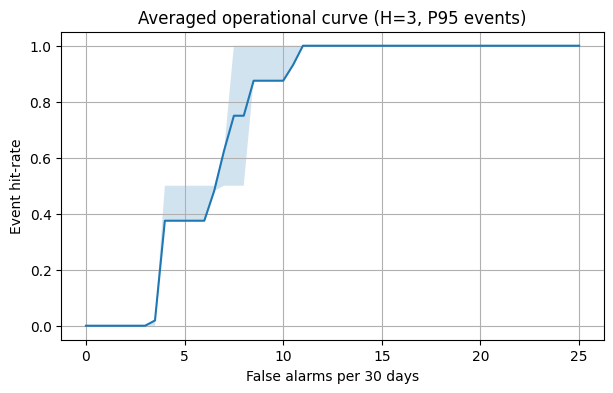

In [ ]:
# --- Save figure for the paper ---
plt.figure(figsize=(7,4))
plt.plot(grid_fa, hr_mean)
plt.fill_between(grid_fa, hr_p25, hr_p75, alpha=0.2)
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate")
plt.title(f"Averaged operational curve (H={H}, P{PERCENTILE} events)")
plt.grid(True)

out_png = "hit-rate vs FA30d_N2O_dataset.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
out_png

In [ ]:
# --- Sensitivity sweep over event severity ---
percentiles = [80, 85, 90, 95, 97]
rows = []

for P in percentiles:
    thr = np.nanpercentile(n2o_train.values, P)
    ev = (n2o_daily_max >= thr)
    yP = make_horizon_labels(ev, H=H)

    curvesP = []
    for (train_end, val_end, test_end) in splits:
        s_val, s_test, y_val, y_test = fit_lr_and_score(
            pd.concat([F_train_z, F_val_z, F_test_z], axis=0),
            yP,
            train_end, val_end, test_end
        )
        ev_test = ev.iloc[val_end:test_end]
        fa_grid, hr_grid, _ = operational_curve(s_test, ev_test, grid_fa=grid_fa)
        curvesP.append(hr_grid)

    CP = np.vstack(curvesP)
    hr_meanP = np.nanmean(CP, axis=0)

    # operating points
    op = extract_points(grid_fa, hr_meanP, targets=(1,5,10,20))
    rows.append({
        "percentile": P,
        "event_days_total": int(ev.sum()),
        "hit_rate_at_1_FA30d": float(op.loc[0, "hit_rate_mean"]),
        "hit_rate_at_5_FA30d": float(op.loc[1, "hit_rate_mean"]),
        "hit_rate_at_10_FA30d": float(op.loc[2, "hit_rate_mean"]),
        "hit_rate_at_20_FA30d": float(op.loc[3, "hit_rate_mean"]),
    })

sens = pd.DataFrame(rows)
sens

,percentile,event_days_total,hit_rate_at_1_FA30d,hit_rate_at_5_FA30d,hit_rate_at_10_FA30d,hit_rate_at_20_FA30d
0,80,79,0.111111,0.194444,0.444444,0.777778
1,85,59,0.000000,0.166667,0.375000,0.666667
2,90,39,0.000000,0.791667,1.000000,1.000000
3,95,21,0.000000,0.375000,0.875000,1.000000
4,97,13,0.000000,1.000000,1.000000,1.000000


In [ ]:
# --- Event diagnostics: runs, durations, summary ---
def event_run_statistics(event_days_bool):
    """
    event_days_bool: pd.Series of booleans indexed by date (True = event day)

    Returns:
        dict with:
        - n_event_days
        - n_events (runs)
        - durations (list of run lengths)
        - duration_mean
        - duration_median
        - duration_max
    """
    # Ensure boolean numpy array
    e = event_days_bool.astype(bool).values

    n_event_days = int(e.sum())

    durations = []
    current_len = 0

    for val in e:
        if val:
            current_len += 1
        else:
            if current_len > 0:
                durations.append(current_len)
                current_len = 0

    # Catch last run if series ends with an event
    if current_len > 0:
        durations.append(current_len)

    n_events = len(durations)

    if n_events > 0:
        duration_mean = float(np.mean(durations))
        duration_median = float(np.median(durations))
        duration_max = int(np.max(durations))
    else:
        duration_mean = np.nan
        duration_median = np.nan
        duration_max = 0

    return {
        "n_event_days": n_event_days,
        "n_events": n_events,
        "durations": durations,
        "duration_mean": duration_mean,
        "duration_median": duration_median,
        "duration_max": duration_max,
    }

# --- Run diagnostics for your current event definition ---
stats = event_run_statistics(event_days)

stats

{'n_event_days': 21,
 'n_events': 16,
 'durations': [2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 3, 2, 1, 1, 1, 1],
 'duration_mean': 1.3125,
 'duration_median': 1.0,
 'duration_max': 3}

In [ ]:
rows = []

for P in [90, 95, 97]:
    thr = np.nanpercentile(n2o_train.values, P)
    evP = (n2o_daily_max >= thr)
    s = event_run_statistics(evP)
    rows.append({
        "percentile": P,
        **{k: s[k] for k in ["n_event_days", "n_events", "duration_mean", "duration_median", "duration_max"]}
    })

pd.DataFrame(rows)

,percentile,n_event_days,n_events,duration_mean,duration_median,duration_max
0,90,39,23,1.695652,1.0,4
1,95,21,16,1.312500,1.0,3
2,97,13,11,1.181818,1.0,2
